The final test accuracy of the model is 98.55% and the final training accuracy is 99.68%.



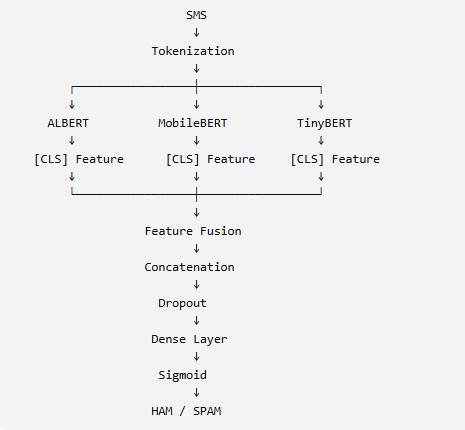

In [ ]:
!pip uninstall -y transformers accelerate peft -q

!pip install --no-cache-dir -q \
    "transformers==5.15.1" \
    "accelerate==1.14.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 256.3 MB/s eta 0:00:00


In [ ]:
import torch
import transformers
import accelerate

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

from transformers import AutoTokenizer, AutoModel

print("Transformers import successful!")

PyTorch: 2.6.0+cu124
Transformers: 5.15.1
Accelerate: 1.14.0
Transformers import successful!


In [ ]:
albert_tokenizer = AutoTokenizer.from_pretrained(
    "albert-base-v2"
)

albert_model = AutoModel.from_pretrained(
    "albert-base-v2"
)

print("ALBERT loaded successfully!")

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ALBERT loaded successfully!


In [ ]:
mobilebert_tokenizer = AutoTokenizer.from_pretrained(
    "google/mobilebert-uncased"
)

mobilebert_model = AutoModel.from_pretrained(
    "google/mobilebert-uncased"
)

print("MobileBERT loaded successfully!")

Loading weights:   0%|          | 0/1111 [00:00<?, ?it/s]

[transformers] MobileBertModel LOAD REPORT from: google/mobilebert-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.dense.weight               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MobileBERT loaded successfully!


In [ ]:
tinybert_tokenizer = AutoTokenizer.from_pretrained(
    "huawei-noah/TinyBERT_General_4L_312D"
)

tinybert_model = AutoModel.from_pretrained(
    "huawei-noah/TinyBERT_General_4L_312D"
)

print("TinyBERT loaded successfully!")

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TinyBERT loaded successfully!


In [ ]:
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import time

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModel
)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.6.0+cu124


In [ ]:
data=pd.read_csv('/content/spam.csv', encoding='latin1')

In [ ]:
data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)
data.columns = ['label', 'message']

In [ ]:
# Dataset Size
print(
    "Total SMS messages:",
    len(data)
)

print(
    "Dataset shape:",
    data.shape
)

Total SMS messages: 5572
Dataset shape: (5572, 2)


In [ ]:
# Missing Values
print(
    data.isnull().sum()
)

label      0
message    0
dtype: int64


In [ ]:
data = data.dropna(
    subset=["message", "label"]
).reset_index(drop=True)

In [ ]:
#SMS Character Length
data["char_length"] = data[
    "message"
].apply(len)

print(
    "Minimum SMS length:",
    data["char_length"].min()
)

print(
    "Maximum SMS length:",
    data["char_length"].max()
)

print(
    "Average SMS length:",
    data["char_length"].mean()
)

Minimum SMS length: 2
Maximum SMS length: 910
Average SMS length: 80.11880832735105


In [ ]:
# Average Number of Words
data["word_count"] = data[
    "message"
].apply(
    lambda x: len(x.split())
)

print(
    "Average words per SMS:",
    data["word_count"].mean()
)

Average words per SMS: 15.494436468054559


In [ ]:

# Text Preprocessing
def clean_text(text):

    text = text.lower()

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    text = text.strip()

    return text

In [ ]:
# APPLY IT
data["clean_message"] = data[
    "message"
].apply(clean_text)

In [ ]:
# Convert Labels
data["label_num"] = data[
    "label"
].map({
    "ham": 0,
    "spam": 1
})

data[
    ["label", "label_num"]
].head()

,label,label_num
0,ham,0
1,ham,0
2,spam,1
3,ham,0
4,ham,0


In [ ]:

# Remove Duplicate Messages
print(
    "Duplicate messages:",
    data["clean_message"].duplicated().sum()
)

Duplicate messages: 415


In [ ]:

data = data.drop_duplicates(
    subset=["clean_message"]
).reset_index(drop=True)

print(
    "Dataset size after removing duplicates:",
    len(data)
)

Dataset size after removing duplicates: 5157


In [ ]:
# Prepare X and y
X = data[
    "clean_message"
].values

y = data[
    "label_num"
].values

print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (5157,)
y shape: (5157,)


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 4125
Testing samples: 1032


In [ ]:
ALBERT_NAME = "albert-base-v2"
MOBILEBERT_NAME = "google/mobilebert-uncased"
TINYBERT_NAME = "huawei-noah/TinyBERT_General_4L_312D"

MAX_LEN = 128
BATCH_SIZE = 2
EPOCHS = 5
LEARNING_RATE = 2e-5
DROPOUT = 0.30
DENSE_HIDDEN = 128

print("Configuration ready.")

Configuration ready.


In [ ]:
# Load Tokenizers
albert_tokenizer = AutoTokenizer.from_pretrained(
    ALBERT_NAME
)

mobilebert_tokenizer = AutoTokenizer.from_pretrained(
    MOBILEBERT_NAME
)

tinybert_tokenizer = AutoTokenizer.from_pretrained(
    TINYBERT_NAME
)

print("All three tokenizers loaded successfully.")

All three tokenizers loaded successfully.


In [ ]:
# Tokenization Example
sample_sms = X_train[0]

print("Original SMS:")
print(sample_sms)

print("\nALBERT Tokens:")
print(
    albert_tokenizer.tokenize(
        sample_sms
    )
)

print("\nMobileBERT Tokens:")
print(
    mobilebert_tokenizer.tokenize(
        sample_sms
    )
)

print("\nTinyBERT Tokens:")
print(
    tinybert_tokenizer.tokenize(
        sample_sms
    )
)

Original SMS:
haha okay... today weekend leh...

ALBERT Tokens:
['▁ha', 'ha', '▁okay', '.', '.', '.', '▁today', '▁weekend', '▁', 'leh', '.', '.', '.']

MobileBERT Tokens:
['ha', '##ha', 'okay', '.', '.', '.', 'today', 'weekend', 'le', '##h', '.', '.', '.']

TinyBERT Tokens:
['ha', '##ha', 'okay', '.', '.', '.', 'today', 'weekend', 'le', '##h', '.', '.', '.']


In [ ]:
# Dataset Class
class ThreeSLMDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        albert_tokenizer,
        mobilebert_tokenizer,
        tinybert_tokenizer,
        max_len
    ):

        self.texts = texts
        self.labels = labels

        self.albert_tokenizer = (
            albert_tokenizer
        )

        self.mobilebert_tokenizer = (
            mobilebert_tokenizer
        )

        self.tinybert_tokenizer = (
            tinybert_tokenizer
        )

        self.max_len = max_len

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        text = str(
            self.texts[idx]
        )

        label = self.labels[idx]

        albert_encoding = (
            self.albert_tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_attention_mask=True,
                return_tensors="pt"
            )
        )

        mobilebert_encoding = (
            self.mobilebert_tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_attention_mask=True,
                return_tensors="pt"
            )
        )

        tinybert_encoding = (
            self.tinybert_tokenizer(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_attention_mask=True,
                return_tensors="pt"
            )
        )

        return {

            "albert_input_ids":
                albert_encoding[
                    "input_ids"
                ].flatten(),

            "albert_attention_mask":
                albert_encoding[
                    "attention_mask"
                ].flatten(),

            "mobilebert_input_ids":
                mobilebert_encoding[
                    "input_ids"
                ].flatten(),

            "mobilebert_attention_mask":
                mobilebert_encoding[
                    "attention_mask"
                ].flatten(),

            "tinybert_input_ids":
                tinybert_encoding[
                    "input_ids"
                ].flatten(),

            "tinybert_attention_mask":
                tinybert_encoding[
                    "attention_mask"
                ].flatten(),

            "label":
                torch.tensor(
                    label,
                    dtype=torch.float
                )
        }

In [ ]:
# Create Training Dataset
train_dataset = ThreeSLMDataset(
    X_train,
    y_train,
    albert_tokenizer,
    mobilebert_tokenizer,
    tinybert_tokenizer,
    MAX_LEN
)

print(
    "Training dataset created."
)

Training dataset created.


In [ ]:
# Create Testing Dataset
test_dataset = ThreeSLMDataset(
    X_test,
    y_test,
    albert_tokenizer,
    mobilebert_tokenizer,
    tinybert_tokenizer,
    MAX_LEN
)

print(
    "Testing dataset created."
)

Testing dataset created.


In [ ]:

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

Training batches: 2063
Testing batches: 516


In [ ]:


# Check Batch
batch = next(
    iter(train_loader)
)

print(
    "ALBERT input:",
    batch[
        "albert_input_ids"
    ].shape
)

print(
    "MobileBERT input:",
    batch[
        "mobilebert_input_ids"
    ].shape
)

print(
    "TinyBERT input:",
    batch[
        "tinybert_input_ids"
    ].shape
)

print(
    "Labels:",
    batch["label"].shape
)

ALBERT input: torch.Size([2, 128])
MobileBERT input: torch.Size([2, 128])
TinyBERT input: torch.Size([2, 128])
Labels: torch.Size([2])


In [ ]:
# Define the Hybrid SLM Model
class ALBERT_MobileBERT_TinyBERT(
    nn.Module
):

    def __init__(
        self,
        albert_name,
        mobilebert_name,
        tinybert_name,
        dense_hidden=128,
        dropout=0.30
    ):

        super(
            ALBERT_MobileBERT_TinyBERT,
            self
        ).__init__()

        # -------------------------
        # ALBERT
        # -------------------------

        self.albert = AutoModel.from_pretrained(
            albert_name
        )

        # -------------------------
        # MobileBERT
        # -------------------------

        self.mobilebert = AutoModel.from_pretrained(
            mobilebert_name
        )

        # -------------------------
        # TinyBERT
        # -------------------------

        self.tinybert = AutoModel.from_pretrained(
            tinybert_name
        )

        # Hidden dimensions
        albert_dim = (
            self.albert.config.hidden_size
        )

        mobilebert_dim = (
            self.mobilebert.config.hidden_size
        )

        tinybert_dim = (
            self.tinybert.config.hidden_size
        )

        # Combined feature size
        combined_dim = (
            albert_dim
            + mobilebert_dim
            + tinybert_dim
        )

        print(
            "ALBERT hidden size:",
            albert_dim
        )

        print(
            "MobileBERT hidden size:",
            mobilebert_dim
        )

        print(
            "TinyBERT hidden size:",
            tinybert_dim
        )

        print(
            "Combined feature size:",
            combined_dim
        )

        # Dropout
        self.dropout = nn.Dropout(
            dropout
        )

        # Fusion layer
        self.fc1 = nn.Linear(
            combined_dim,
            dense_hidden
        )

        # Output layer
        self.output = nn.Linear(
            dense_hidden,
            1
        )

    def forward(
        self,

        albert_input_ids,
        albert_attention_mask,

        mobilebert_input_ids,
        mobilebert_attention_mask,

        tinybert_input_ids,
        tinybert_attention_mask
    ):

        # -------------------------
        # ALBERT
        # -------------------------

        albert_output = self.albert(
            input_ids=albert_input_ids,
            attention_mask=albert_attention_mask
        )

        # First token representation
        albert_features = (
            albert_output.last_hidden_state[:, 0, :]
        )

        # -------------------------
        # MobileBERT
        # -------------------------

        mobilebert_output = self.mobilebert(
            input_ids=mobilebert_input_ids,
            attention_mask=mobilebert_attention_mask
        )

        mobilebert_features = (
            mobilebert_output.last_hidden_state[:, 0, :]
        )

        # -------------------------
        # TinyBERT
        # -------------------------

        tinybert_output = self.tinybert(
            input_ids=tinybert_input_ids,
            attention_mask=tinybert_attention_mask
        )

        tinybert_features = (
            tinybert_output.last_hidden_state[:, 0, :]
        )

        # -------------------------
        # Feature Fusion
        # -------------------------

        combined_features = torch.cat(
            [
                albert_features,
                mobilebert_features,
                tinybert_features
            ],
            dim=1
        )

        # -------------------------
        # Dropout
        # -------------------------

        x = self.dropout(
            combined_features
        )

        # -------------------------
        # Dense
        # -------------------------

        x = torch.relu(
            self.fc1(x)
        )

        x = self.dropout(x)

        # -------------------------
        # Output
        # -------------------------

        output = self.output(x)

        return output.squeeze(1)

In [ ]:
import torch
import transformers
import accelerate

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

PyTorch: 2.6.0+cu124
Transformers: 5.15.1
Accelerate: 1.14.0


In [ ]:
from transformers import AutoTokenizer, AutoModel

print("Transformers is working!")

Transformers is working!


In [ ]:
from transformers import AutoModel

albert_test = AutoModel.from_pretrained(
    "albert-base-v2"
)

print("ALBERT loaded successfully!")

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ALBERT loaded successfully!


In [ ]:
mobilebert_test = AutoModel.from_pretrained(
    "google/mobilebert-uncased"
)

print("MobileBERT loaded successfully!")

Loading weights:   0%|          | 0/1111 [00:00<?, ?it/s]

[transformers] MobileBertModel LOAD REPORT from: google/mobilebert-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.dense.weight               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MobileBERT loaded successfully!


In [ ]:

import torch

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = ALBERT_MobileBERT_TinyBERT(
    albert_name=ALBERT_NAME,
    mobilebert_name=MOBILEBERT_NAME,
    tinybert_name=TINYBERT_NAME,
    dense_hidden=DENSE_HIDDEN,
    dropout=DROPOUT
)

model = model.to(device)

print(
    "Hybrid model created successfully."
)

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/1111 [00:00<?, ?it/s]

[transformers] MobileBertModel LOAD REPORT from: google/mobilebert-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.dense.weight               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: huawei-noah/TinyBERT_General_4L_312D
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.weight          | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
fit_denses.{0, 1, 2, 3, 4}.bias            | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ALBERT hidden size: 768
MobileBERT hidden size: 512
TinyBERT hidden size: 312
Combined feature size: 1592
Hybrid model created successfully.


In [ ]:
# Count Parameters
total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    "Total parameters:",
    total_parameters
)

print(
    "Trainable parameters:",
    trainable_parameters
)

Total parameters: 50819753
Trainable parameters: 50819753


In [ ]:
# Loss Function
criterion = nn.BCEWithLogitsLoss()

print(
    "Loss Function: "
    "Binary Cross Entropy with Logits"
)

Loss Function: Binary Cross Entropy with Logits


In [ ]:
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

print(
    "Optimizer: AdamW"
)

print(
    "Learning Rate:",
    LEARNING_RATE
)

Optimizer: AdamW
Learning Rate: 2e-05


In [ ]:
# Training Function
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0

    correct = 0

    total = 0

    for batch in loader:

        albert_input_ids = batch[
            "albert_input_ids"
        ].to(device)

        albert_attention_mask = batch[
            "albert_attention_mask"
        ].to(device)

        mobilebert_input_ids = batch[
            "mobilebert_input_ids"
        ].to(device)

        mobilebert_attention_mask = batch[
            "mobilebert_attention_mask"
        ].to(device)

        tinybert_input_ids = batch[
            "tinybert_input_ids"
        ].to(device)

        tinybert_attention_mask = batch[
            "tinybert_attention_mask"
        ].to(device)

        labels = batch[
            "label"
        ].to(device)

        optimizer.zero_grad()

        outputs = model(

            albert_input_ids,
            albert_attention_mask,

            mobilebert_input_ids,
            mobilebert_attention_mask,

            tinybert_input_ids,
            tinybert_attention_mask

        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * len(labels)
        )

        probabilities = torch.sigmoid(
            outputs
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += len(labels)

    epoch_loss = (
        total_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return (
        epoch_loss,
        epoch_accuracy
    )

In [ ]:
# Evaluation Function
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0

    correct = 0

    total = 0

    all_labels = []

    all_predictions = []

    all_probabilities = []

    with torch.no_grad():

        for batch in loader:

            albert_input_ids = batch[
                "albert_input_ids"
            ].to(device)

            albert_attention_mask = batch[
                "albert_attention_mask"
            ].to(device)

            mobilebert_input_ids = batch[
                "mobilebert_input_ids"
            ].to(device)

            mobilebert_attention_mask = batch[
                "mobilebert_attention_mask"
            ].to(device)

            tinybert_input_ids = batch[
                "tinybert_input_ids"
            ].to(device)

            tinybert_attention_mask = batch[
                "tinybert_attention_mask"
            ].to(device)

            labels = batch[
                "label"
            ].to(device)

            outputs = model(

                albert_input_ids,
                albert_attention_mask,

                mobilebert_input_ids,
                mobilebert_attention_mask,

                tinybert_input_ids,
                tinybert_attention_mask

            )

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item()
                * len(labels)
            )

            probabilities = torch.sigmoid(
                outputs
            )

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += len(labels)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    loss = (
        total_loss / total
    )

    accuracy = (
        correct / total
    )

    return (
        loss,
        accuracy,
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities)
    )

In [ ]:
# Train Model
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(EPOCHS):

    train_loss, train_accuracy = (
        train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device
        )
    )

    val_loss, val_accuracy, _, _, _ = (
        evaluate_model(
            model,
            test_loader,
            criterion,
            device
        )
    )

    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_accuracy
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
    )

    print(
        f"Train Loss: "
        f"{train_loss:.4f}"
    )

    print(
        f"Train Accuracy: "
        f"{train_accuracy:.4f}"
    )

    print(
        f"Validation Loss: "
        f"{val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{val_accuracy:.4f}"
    )

    print("-" * 50)

training_time = (
    time.time() - start_time
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

Epoch 1/5
Train Loss: 6590.1010
Train Accuracy: 0.9302
Validation Loss: 0.0765
Validation Accuracy: 0.9826
--------------------------------------------------
Epoch 2/5
Train Loss: 0.5295
Train Accuracy: 0.9804
Validation Loss: 0.0365
Validation Accuracy: 0.9884
--------------------------------------------------
Epoch 3/5
Train Loss: 0.1711
Train Accuracy: 0.9910
Validation Loss: 0.0831
Validation Accuracy: 0.9826
--------------------------------------------------
Epoch 4/5
Train Loss: 0.0268
Train Accuracy: 0.9942
Validation Loss: 0.0314
Validation Accuracy: 0.9913
--------------------------------------------------
Epoch 5/5
Train Loss: 0.0156
Train Accuracy: 0.9968
Validation Loss: 0.0656
Validation Accuracy: 0.9855
--------------------------------------------------
Training time: 2358.28 seconds


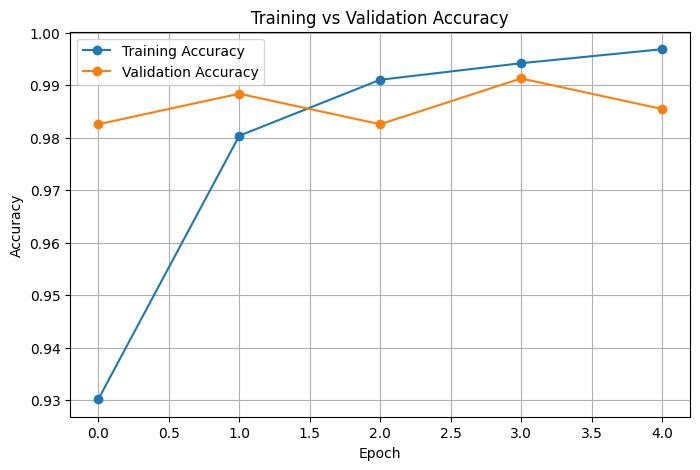

In [ ]:
# Accuracy Graph
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

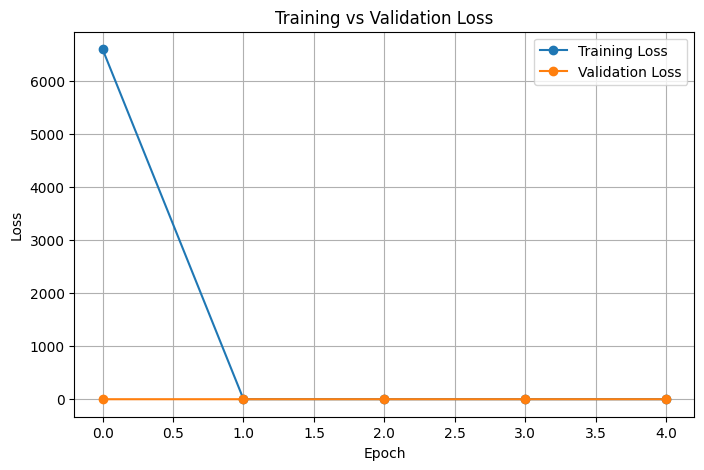

In [ ]:
# Loss Graph
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Test the Final Model
test_loss, test_accuracy, y_true, y_pred, y_probability = (
    evaluate_model(
        model,
        test_loader,
        criterion,
        device
    )
)

print(
    f"Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Test Accuracy: 98.55%


In [ ]:
# Accuracy, Precision, Recall and F1
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

Accuracy : 0.9855
Precision: 0.9669
Recall   : 0.9141
F1-score : 0.9398


In [ ]:
# Confusion Matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[900   4]
 [ 11 117]]


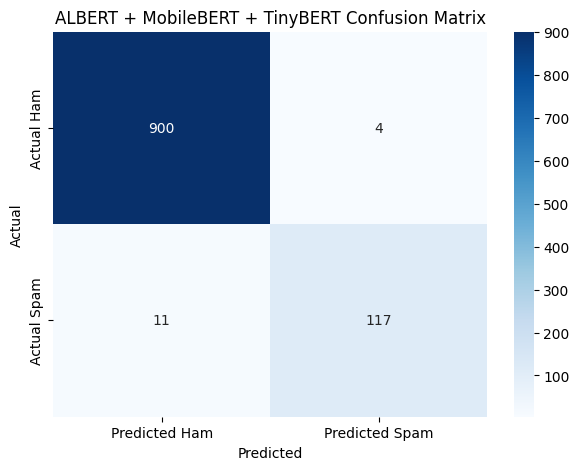

In [ ]:
# Confusion Matrix Visualization
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Ham",
        "Predicted Spam"
    ],
    yticklabels=[
        "Actual Ham",
        "Actual Spam"
    ]
)

plt.title(
    "ALBERT + MobileBERT + TinyBERT Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# Classification Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Ham",
            "Spam"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       904
        Spam       0.97      0.91      0.94       128

    accuracy                           0.99      1032
   macro avg       0.98      0.95      0.97      1032
weighted avg       0.99      0.99      0.99      1032



In [ ]:
# Evaluation Table
evaluation_table = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation_table

,Metric,Score
0,Accuracy,0.985465
1,Precision,0.966942
2,Recall,0.914062
3,F1-score,0.939759


In [ ]:
# Find Incorrect Predictions
error_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Total incorrect predictions:",
    len(error_indices)
)

Total incorrect predictions: 15


In [ ]:
# Error Analysis
error_data = []

for idx in error_indices:

    actual = int(
        y_true[idx]
    )

    predicted = int(
        y_pred[idx]
    )

    probability = float(
        y_probability[idx]
    )

    if predicted == 1:

        confidence = probability

    else:

        confidence = 1 - probability

    actual_label = (
        "Spam"
        if actual == 1
        else "Ham"
    )

    predicted_label = (
        "Spam"
        if predicted == 1
        else "Ham"
    )

    error_data.append({

        "SMS Text":
            X_test[idx],

        "Actual Label":
            actual_label,

        "Predicted Label":
            predicted_label,

        "Confidence":
            confidence
    })

error_df = pd.DataFrame(
    error_data
)

error_df.head(10)

,SMS Text,Actual Label,Predicted Label,Confidence
0,cashbin.co.uk (get lots of cash this weekend!)...,Spam,Ham,0.998374
1,"sms. ac jsco: energy is high, but u may not kn...",Spam,Ham,0.871486
2,sorry! u can not unsubscribe yet. the mob offe...,Spam,Ham,0.945826
3,themob>yo yo yo-here comes a new selection of ...,Spam,Ham,0.998804
4,babe: u want me dont u baby! im nasty and have...,Spam,Ham,0.957843
5,(bank of granite issues strong-buy) explosive ...,Spam,Ham,0.966595
6,was playng 9 doors game and gt racing on phone...,Ham,Spam,0.843711
7,3. you have received your mobile content. enjoy,Spam,Ham,0.998074
8,thesmszone.com lets you send free anonymous an...,Spam,Ham,0.998523
9,for many things its an antibiotic and it can b...,Ham,Spam,0.737734


In [ ]:
# Identify Possible Error Reason
def find_error_reason(text):

    text_lower = text.lower()

    if (
        "http" in text_lower
        or "www" in text_lower
        or ".com" in text_lower
    ):

        return "URL"

    if re.search(
        r"\d+",
        text_lower
    ):

        return "Numbers"

    if len(
        text.split()
    ) <= 4:

        return "Short message"

    if len(
        text.split()
    ) >= 30:

        return "Long message"

    promotional_words = [

        "free",
        "win",
        "winner",
        "prize",
        "offer",
        "claim",
        "cash",
        "urgent",
        "bonus"

    ]

    if any(
        word in text_lower
        for word in promotional_words
    ):

        return "Promotional language"

    return "Informal or ambiguous wording"

In [ ]:
# Prediction Function
def predict_sms(text):

    model.eval()

    cleaned_text = clean_text(
        text
    )

    # ALBERT
    albert_encoding = (
        albert_tokenizer(
            cleaned_text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
    )

    # MobileBERT
    mobilebert_encoding = (
        mobilebert_tokenizer(
            cleaned_text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
    )

    # TinyBERT
    tinybert_encoding = (
        tinybert_tokenizer(
            cleaned_text,
            add_special_tokens=True,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )
    )

    with torch.no_grad():

        output = model(

            albert_encoding[
                "input_ids"
            ].to(device),

            albert_encoding[
                "attention_mask"
            ].to(device),

            mobilebert_encoding[
                "input_ids"
            ].to(device),

            mobilebert_encoding[
                "attention_mask"
            ].to(device),

            tinybert_encoding[
                "input_ids"
            ].to(device),

            tinybert_encoding[
                "attention_mask"
            ].to(device)

        )

        probability = torch.sigmoid(
            output
        ).item()

    if probability >= 0.5:

        prediction = "SPAM"

        confidence = probability

    else:

        prediction = "HAM"

        confidence = 1 - probability

    return (
        prediction,
        confidence
    )

In [ ]:
# Test One SMS
sms = (
    "Congratulations! You have won "
    "a free iPhone. Click here now!"
)

prediction, confidence = predict_sms(
    sms
)

print(
    "SMS:",
    sms
)

print(
    "Prediction:",
    prediction
)

print(
    f"Confidence: "
    f"{confidence * 100:.2f}%"
)

SMS: Congratulations! You have won a free iPhone. Click here now!
Prediction: HAM
Confidence: 89.56%


In [ ]:
# Final Evaluation Table
final_evaluation_table = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "ALBERT + MobileBERT + TinyBERT": [

        accuracy,
        precision,
        recall,
        f1

    ]
})

final_evaluation_table

,Metric,ALBERT + MobileBERT + TinyBERT
0,Accuracy,0.985465
1,Precision,0.966942
2,Recall,0.914062
3,F1-score,0.939759


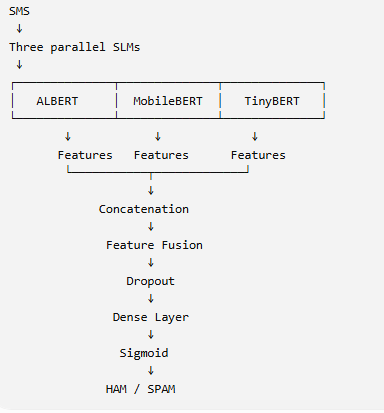

The proposed hybrid SLM model combines three pretrained lightweight Transformer language models: ALBERT, MobileBERT, and TinyBERT. The same SMS input is independently processed by all three SLMs to generate contextual feature representations. The representations obtained from the three models are concatenated to perform feature fusion. The fused representation is passed through dropout and a dense classification layer, followed by a sigmoid output for binary classification into Ham or Spam.